<a href="https://colab.research.google.com/github/HRashidLiaquat/lessons-learned/blob/Logstic_Regression_FashionMNIST/Demo1_Project_Reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0 Import important libriries

1 Get data Ready

3 Data preprocessing

4 Show Raw data by using matpolab

5 build a Modul

6 Bulid a traning loop

7 define loss and activaction function

8 Module validaction

9 Test with New data point

10 Save Model **bold text**


O Import important lobraries

In [32]:
import torch
import torch.nn as nn
import time
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

**Get Data Ready(turn into tensors, and batches)**

In [33]:
train_dataset = datasets.FashionMNIST(root = '/dataset', train= True, transform = transforms.ToTensor(), download=True)
test_dataset  = datasets.FashionMNIST(root = '/dataset', train = False, transform=transforms.ToTensor(), download=True)

In [34]:
train_dataset,test_dataset

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: /dataset
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: /dataset
     Split: Test
     StandardTransform
 Transform: ToTensor())

**Data Convert into batch**

In [35]:
batch_size = 64

In [36]:
train_loade = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
testloader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

In [37]:
len(train_loade),len(testloader)

(938, 157)

**Bulid a Logstic Regression Model**

In [38]:
class LogsticRegression(nn.Module):
  def __init__(self,input_dim,n_class):
    super().__init__()
    self.linear=nn.Linear(input_dim,n_class)

  def forward(self,x):
    out= self.linear(x)
    return out

In [39]:
model=LogsticRegression(28 * 28 , 10)

In [40]:
model

LogsticRegression(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)

In [41]:
device= 'cuda' if torch.cuda.is_available() else 'cpu'

In [42]:
learning_rate=1e-3

**Define Loos and optimizer**

In [43]:
criterion = nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)

**Build a traning loop**

In [44]:
num_epochs = 50

In [45]:
model.to(device)
for epoch in range(num_epochs):
  print('* ' *10)
  print(f'epochn{epoch +1}')
  running_loss=0.0
  running_acc=0.0
  model.train()
  for i , data in enumerate(train_loade, 1):
    img,label=data
    img=img.view(img.size(0), -1)
    img=img.to(device)
    label=label.to(device)
    out=model(img)
    loss=criterion(out,label)
    running_loss+=loss.item()
    _,pred=torch.max(out,1)
    running_acc+=(pred==label).float().mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if i % 300 == 0:
      print(f'[{epoch+1}/ {num_epochs}] loss: {running_loss/i:.6f}, acc: {running_acc/i:.6f}')
  print(f'Finish {epoch +1} epoch,loss : {running_loss/i:.6f}, acc:{running_acc/i:.6f}')

* * * * * * * * * * 
epochn1
[1/ 50] loss: 2.016232, acc: 0.399531
[1/ 50] loss: 1.833395, acc: 0.516458
[1/ 50] loss: 1.701544, acc: 0.563733
Finish 1 epoch,loss : 1.687155, acc:0.567847
* * * * * * * * * * 
epochn2
[2/ 50] loss: 1.277952, acc: 0.669531
[2/ 50] loss: 1.232503, acc: 0.670495
[2/ 50] loss: 1.194791, acc: 0.673229
Finish 2 epoch,loss : 1.189338, acc:0.674740
* * * * * * * * * * 
epochn3
[3/ 50] loss: 1.054350, acc: 0.690990
[3/ 50] loss: 1.035543, acc: 0.693099
[3/ 50] loss: 1.017793, acc: 0.695677
Finish 3 epoch,loss : 1.015478, acc:0.695996
* * * * * * * * * * 
epochn4
[4/ 50] loss: 0.947522, acc: 0.709219
[4/ 50] loss: 0.937211, acc: 0.712943
[4/ 50] loss: 0.925197, acc: 0.716458
Finish 4 epoch,loss : 0.924127, acc:0.716251
* * * * * * * * * * 
epochn5
[5/ 50] loss: 0.881657, acc: 0.727969
[5/ 50] loss: 0.872426, acc: 0.729661
[5/ 50] loss: 0.865714, acc: 0.731024
Finish 5 epoch,loss : 0.865895, acc:0.731193
* * * * * * * * * * 
epochn6
[6/ 50] loss: 0.835210, acc: 0.

**Model validate**

In [46]:
model.eval()
eval_loss=0.
eval_acc=0.
for data in testloader:
  img,label=data
  img=img.view(img.size(0), -1)
  img=img.to(device)
  label=label.to(device)
  with torch.no_grad():
    out=model(img)
    loss=criterion(out,label)
  eval_loss+=loss.item()
  _,pred=torch.max(out,1)
  eval_acc+=(pred==label).float().mean()
print(f'test loss: { eval_loss/len(testloader):.6f}, Acc : {eval_acc / len(train_loade):.6f}')

test loss: 0.559099, Acc : 0.136027


**Visulized data**

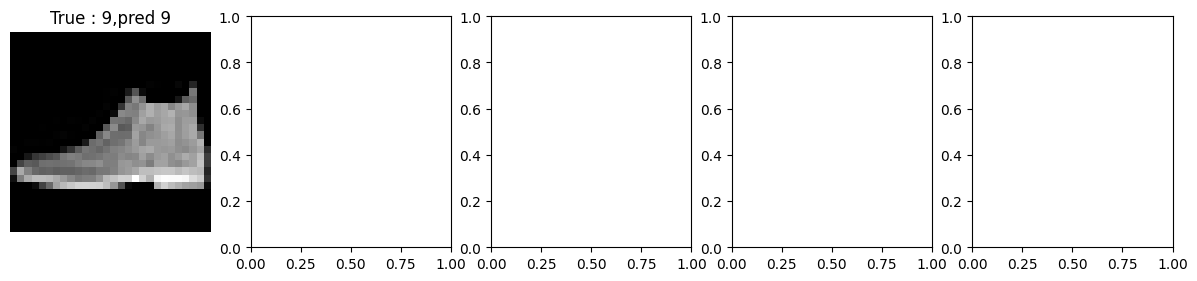

In [47]:
images, labels=next(iter(testloader))
images=images.reshape(-1,28*28).to(device)
labels=labels.to(device)
outputs=model(images)
_,predicted=torch.max(outputs,1)
fig, ax= plt.subplots(1,5, figsize=(15,3))
for i in range(5):
  ax[i].imshow(images[i].reshape(28,28).cpu(),cmap='gray')
  ax[i].set_title(f'True : { labels[i].item()},pred {predicted[i].item()}')
  ax[i].axis('off')
  plt.show()